Saving Modified_SQL_Dataset.csv to Modified_SQL_Dataset (1).csv
                                               Query  Label
0                  " or pg_sleep  (  __TIME__  )  --      1
1  create user name identified by pass123 tempora...      1
2   AND 1  =  utl_inaddr.get_host_address   (    ...      1
3   select * from users where id  =  '1' or @ @1 ...      1
4   select * from users where id  =  1 or 1#"  ( ...      1
Index(['Query', 'Label'], dtype='object')

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      3893
           1       0.97      0.90      0.94      2291

    accuracy                           0.95      6184
   macro avg       0.96      0.94      0.95      6184
weighted avg       0.96      0.95      0.95      6184



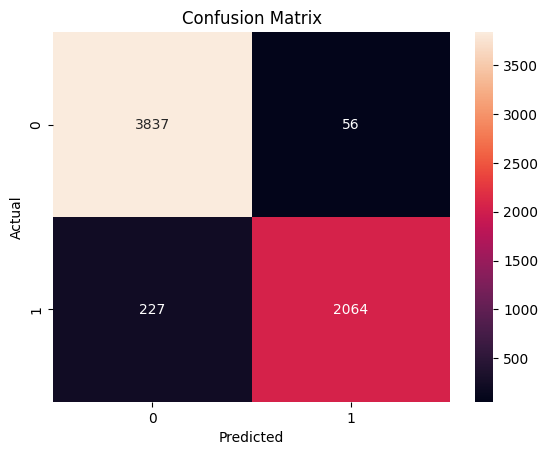

⚠️ SQL Injection Attack
⚠️ SQL Injection Attack
Naive Bayes Accuracy: 0.9542367399741267
Random Forest Accuracy: 0.809993531694696
✅ Naive Bayes is better


In [2]:

# 1. INSTALL LIBRARIES
!pip install pandas scikit-learn matplotlib seaborn

# 2. UPLOAD DATASET
from google.colab import files
uploaded = files.upload()

#3. IMPORT LIBRARIES
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

 #4. Load Dataset
df = pd.read_csv("Modified_SQL_Dataset.csv")

print(df.head())
print(df.columns)

# 5. CLEAN TEXT
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\W", " ", text)   # remove symbols
    text = re.sub(r"\s+", " ", text)
    return text

df["Query"] = df["Query"].apply(clean_text)

# 6. FEATURES
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Query"])
y = df["Label"]   # 1 = attack, 0 = normal

# 7. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. TRAIN MODEL
model = MultinomialNB()
model.fit(X_train, y_train)

# 9. EVALUATION
y_pred = model.predict(X_test)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


# 10. CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 11. TEST FUNCTION

def predict_query(query):
    query = clean_text(query)
    vec = vectorizer.transform([query])
    pred = model.predict(vec)[0]

    if pred == 1:
        return "⚠️ SQL Injection Attack"
    else:
        return "✅ Normal Query"


# 12. TEST EXAMPLES

print(predict_query("SELECT * FROM users WHERE id = 1"))
print(predict_query("SELECT * FROM users WHERE id = 1 OR 1=1"))

# 8. TRAIN MODELS (NB + RF)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- Naive Bayes ---
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 9. EVALUATION COMPARISON


# Predictions
nb_pred = nb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Accuracy
nb_acc = accuracy_score(y_test, nb_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Naive Bayes Accuracy:", nb_acc)
print("Random Forest Accuracy:", rf_acc)

# 10. CHOOSE BEST MODEL

if rf_acc > nb_acc:
    print("✅ Random Forest is better")
    model = rf_model
else:
    print("✅ Naive Bayes is better")
    model = nb_model
